# H1 — Variable Redundancy Analysis
## Adapted for seasonal aggregated data (Wyscout / `wyscout_sample.csv`)

Evaluates the **collinearity structure** of the seasonal aggregated dataset (`wyscout_sample.csv`). Identifies which pairs of variables share high correlation (|ρ| ≥ 0.80) to guide feature selection and prevent double-counting when designing composite indices and radar visualizations.

## Setup

In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 15)

def _find_data_path() -> Path:
    env_path = os.getenv('DATA_PATH')
    if env_path and Path(env_path).exists():
        return Path(env_path)
    cur = Path.cwd()
    for _ in range(6):
        for candidate in [
            cur / "webapp" / "backend" / "data" / "wyscout_sample.csv",
            cur / "data" / "wyscout_sample.csv",
        ]:
            if candidate.exists():
                return candidate
        if cur.parent == cur:
            break
        cur = cur.parent
    candidates = [
        Path('../../webapp/backend/data/wyscout_sample.csv'),
        Path('../webapp/backend/data/wyscout_sample.csv'),
        Path('webapp/backend/data/wyscout_sample.csv'),
        Path('../../data/wyscout_sample.csv'),
        Path('../data/wyscout_sample.csv'),
        Path('data/wyscout_sample.csv'),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("Could not locate wyscout_sample.csv. Please set DATA_PATH environment variable.")

DATA_PATH = _find_data_path()
df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = [str(c).strip() for c in df.columns]
print(f"Loaded: {df.shape[0]} players, {df.shape[1]} columns")


1144 players with >= 300 minutes (out of 1697 in spreadsheet)


## Automatic Variable Classification

Instead of manually choosing which columns belong to each family (as the original notebook did, hand-curated for the H1 pipeline), classification here is **automatic by naming pattern**: columns with `%` become Percentages, columns with `/90` (and no `%`) become Per 90, and the rest become Raw. Identity columns (player, team, position, nationality) and biographical/contextual variables (age, height, weight, market value, matches, minutes) are excluded — they represent context, not a performance metric.

In [2]:
ID_COLS = {
    "Player", "Team", "Team within selected timeframe", "Position",
    "Birth country", "Passport country", "Foot", "On loan", "Contract expires",
}
CONTEXT_COLS = {"Age", "Market value", "Height", "Weight", "Matches played", "Minutes played"}

numeric_cols = [c for c in df.columns if c not in ID_COLS and c not in CONTEXT_COLS
                and pd.api.types.is_numeric_dtype(df[c])]
PCT_COLS = [c for c in numeric_cols if "%" in c]
PER90_COLS = [c for c in numeric_cols if "/90" in c and c not in PCT_COLS]
RAW_COLS = [c for c in numeric_cols if c not in PCT_COLS and c not in PER90_COLS]

print(f"Raw: {len(RAW_COLS)} columns")
print(f"Per 90: {len(PER90_COLS)} columns")
print(f"Percentages: {len(PCT_COLS)} columns")

Raw: 19 columns
Per 90: 57 columns
Percentages: 24 columns


## 1. RAW Variables (counts and absolute sums)

Seasonal volume metrics. High correlation is expected among them and with minutes played, simply because more time on the pitch produces more events — minimum minutes filter is already applied, but structural volume correlation remains expected.

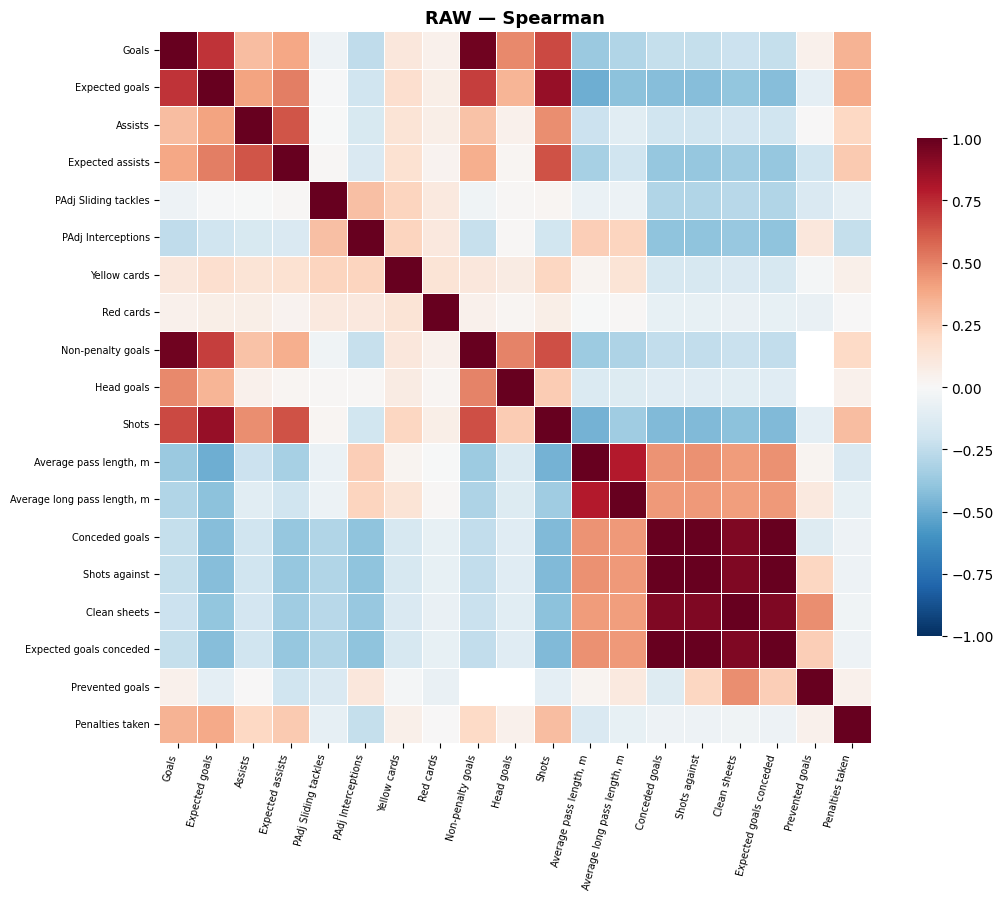

In [3]:
def corr_heatmap(cols, title, method="spearman", figsize=(11, 9)):
    sub = df[cols].dropna(axis=1, how="all")
    corr = sub.corr(method=method)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(corr, cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True,
                linewidths=0.4, cbar_kws={"shrink": 0.7}, ax=ax)
    ax.set_title(f"{title} — Spearman", fontsize=13, fontweight="bold")
    plt.xticks(rotation=75, ha="right", fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()
    return corr


def top_pairs(corr: pd.DataFrame, n=12) -> pd.DataFrame:
    cols = corr.columns.tolist()
    rows = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            v = corr.iloc[i, j]
            if pd.notna(v):
                rows.append((cols[i], cols[j], v))
    rows.sort(key=lambda x: -abs(x[2]))
    return pd.DataFrame(rows[:n], columns=["Variable A", "Variable B", "rho"]).round(3)


corr_raw = corr_heatmap(RAW_COLS, "RAW")

In [4]:
print("Most correlated pairs - RAW")
top_pairs(corr_raw, 12)


Most correlated pairs — RAW


,Variable A,Variable B,rho
0,Shots against,Expected goals conceded,1.000
1,Conceded goals,Expected goals conceded,1.000
2,Conceded goals,Shots against,1.000
3,Goals,Non-penalty goals,0.975
4,Shots against,Clean sheets,0.934
5,Clean sheets,Expected goals conceded,0.933
6,Conceded goals,Clean sheets,0.931
7,Expected goals,Shots,0.873
8,"Average pass length, m","Average long pass length, m",0.797
9,Goals,Expected goals,0.723


## 2. PER 90 Variables (rate metrics)

Counts normalized by playing time. Removes the volume effect and exposes the underlying play style — the family closest to what feeds radars and composite indices.

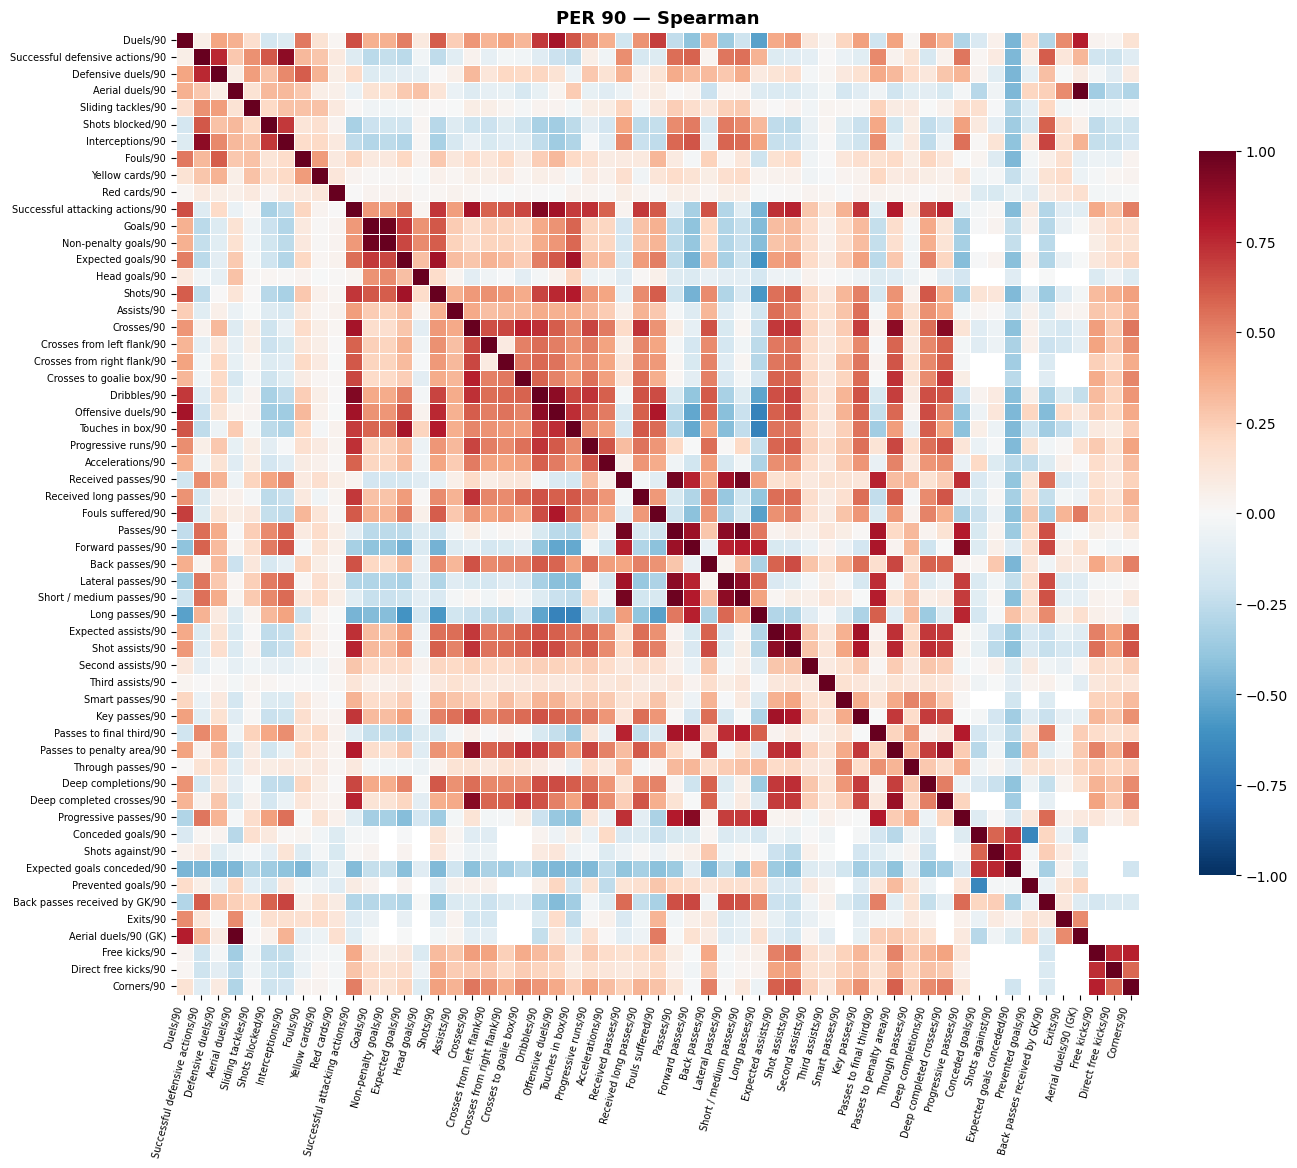

In [5]:
corr_per90 = corr_heatmap(PER90_COLS, "PER 90", figsize=(14, 12))

In [6]:
print("Most correlated pairs - PER 90")
top_pairs(corr_per90, 15)


Most correlated pairs — PER 90


,Variable A,Variable B,rho
0,Aerial duels/90,Aerial duels/90 (GK),1.000
1,Passes/90,Short / medium passes/90,0.982
2,Goals/90,Non-penalty goals/90,0.976
3,Received passes/90,Passes/90,0.966
4,Received passes/90,Short / medium passes/90,0.956
5,Successful attacking actions/90,Dribbles/90,0.922
6,Crosses/90,Deep completed crosses/90,0.910
7,Forward passes/90,Progressive passes/90,0.907
8,Passes/90,Lateral passes/90,0.903
9,Crosses/90,Passes to penalty area/90,0.898


## 3. PERCENTAGE Variables (efficiency rates)

Success/attempt ratios. In principle independent of volume, so any redundancy here is conceptual — not an artifact of normalization.

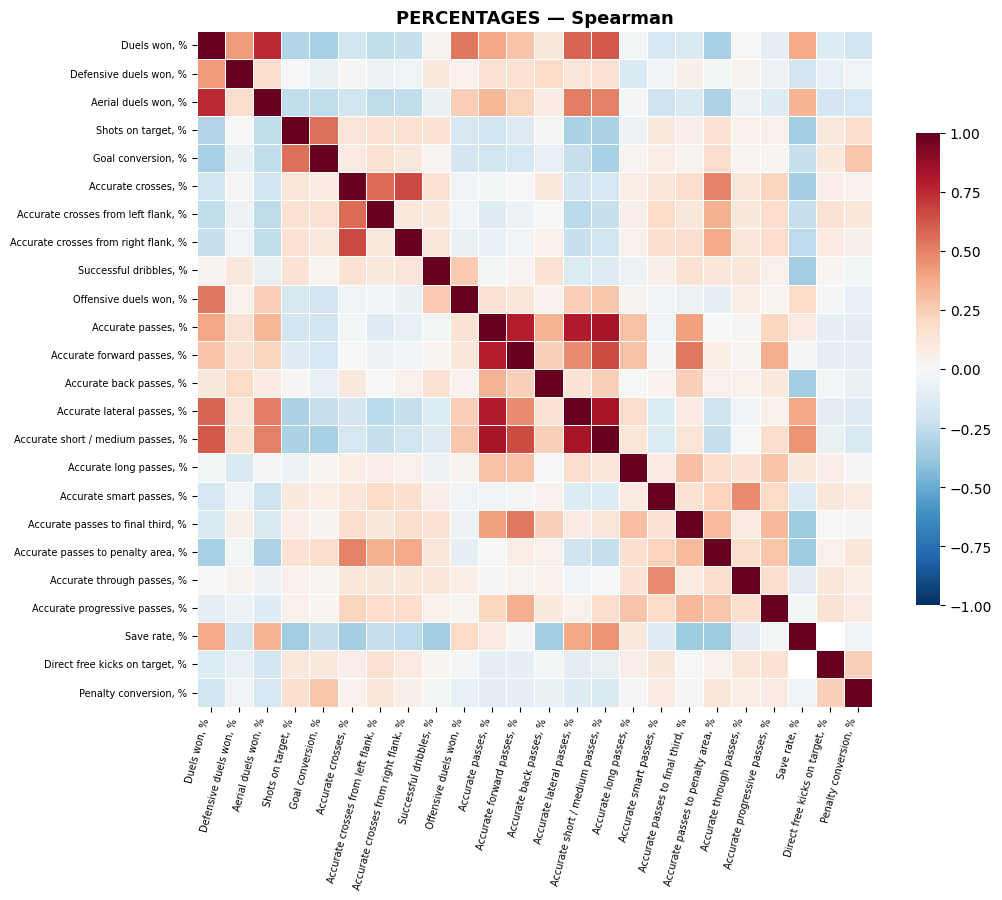

In [7]:
corr_pct = corr_heatmap(PCT_COLS, "PERCENTAGES", figsize=(11, 9))

In [8]:
print("Most correlated pairs - PERCENTAGES")
top_pairs(corr_pct, 12)


Most correlated pairs — PERCENTAGES


,Variable A,Variable B,rho
0,"Accurate lateral passes, %","Accurate short / medium passes, %",0.823
1,"Accurate passes, %","Accurate short / medium passes, %",0.822
2,"Accurate passes, %","Accurate lateral passes, %",0.794
3,"Accurate passes, %","Accurate forward passes, %",0.784
4,"Duels won, %","Aerial duels won, %",0.752
5,"Accurate crosses, %","Accurate crosses from right flank, %",0.657
6,"Accurate forward passes, %","Accurate short / medium passes, %",0.653
7,"Duels won, %","Accurate short / medium passes, %",0.617
8,"Duels won, %","Accurate lateral passes, %",0.585
9,"Accurate crosses, %","Accurate crosses from left flank, %",0.564


## Cross-Group Summary

Redundancy load in each family: how many pairs cross the 0.6 and 0.8 thresholds of |ρ| — the higher the count, the more a family contains variables expressing essentially the same information.

In [9]:
def redundancy_load(corr: pd.DataFrame) -> dict:
    cols = corr.columns.tolist()
    vals = [abs(corr.iloc[i, j]) for i in range(len(cols)) for j in range(i + 1, len(cols)) if pd.notna(corr.iloc[i, j])]
    vals = np.array(vals)
    return {
        "n_variables": len(cols),
        "n_pairs": len(vals),
        "pairs >0.6": int((vals > 0.6).sum()),
        "pairs >0.8": int((vals > 0.8).sum()),
        "median |rho|": float(np.median(vals)) if len(vals) else np.nan,
    }

summary = pd.DataFrame({
    "RAW": redundancy_load(corr_raw),
    "PER 90": redundancy_load(corr_per90),
    "PERCENTAGES": redundancy_load(corr_pct),
}).T
summary.round(3)

,n_variables,n_pairs,pairs >0.6,pairs >0.8,median |rho|
RAW,19.0,169.0,15.0,8.0,0.218
PER 90,57.0,1549.0,139.0,27.0,0.191
PERCENTAGES,24.0,275.0,8.0,2.0,0.132


### Reading the Findings

The pairs at the top of each block divide into two categories:

- **Structural / Tautological** — pairs where one variable is by construction almost identical to another (e.g. `Conceded goals` ↔ `Expected goals conceded`, `Shots against` ↔ `Expected goals conceded` in RAW; duplicate columns with goalkeeper suffixes in PER 90). These pairs are not discoveries; they are direct arithmetic consequences.
- **Substantive** — pairs that are not mathematically bound by definition, but which the empirical sample shows move together (e.g. `Accurate passes, %` ↔ `Accurate short / medium passes, %` in PERCENTAGES, ρ ≈ 0.82 — overall passing control and short pass accuracy represent practically the same player trait in this dataset). These are genuine candidates to choose between when assembling a non-redundant composite index — as done in Section 2 of adapted H1-Space_Control.

Unlike the original notebook (which cites static findings from a precalculated table), the tables above are generated **live** from `wyscout_sample.csv` based on the loaded dataset.